<a href="https://colab.research.google.com/github/lodenaq/SUNY-Canton-Projects/blob/main/Mobile%20Crowd%20Sensing%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Initial Training Shape (Before Spatial Engineering): (11763, 12)
Initial Testing Shape (Before Spatial Engineering): (2543, 12)

Processing unified t-SNE projection maps...


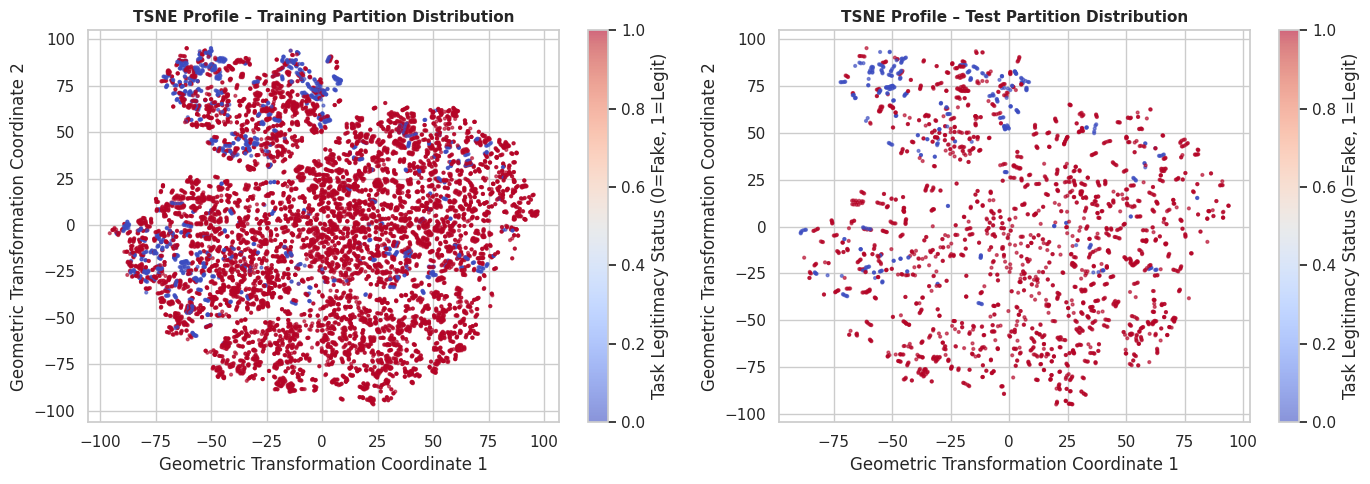


Calculating Baseline Metrics (KNN, SVM, Decision Tree)...
 - Baseline KNN Test F1 Score: 0.9359
 - Baseline SVM Test F1 Score: 0.9456
 - Baseline DecisionTree Test F1 Score: 0.9834

--> Best Baseline Model: DecisionTree (0.9834)


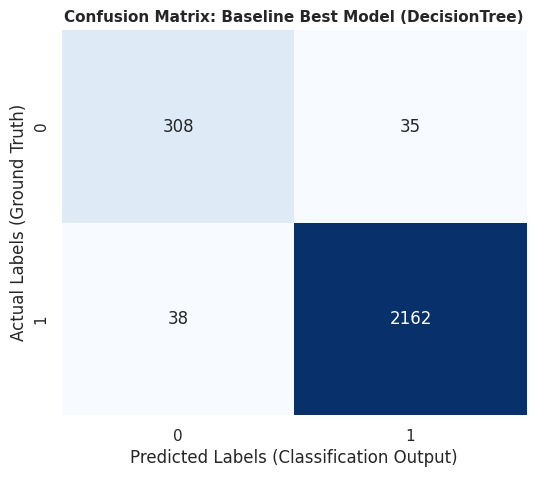

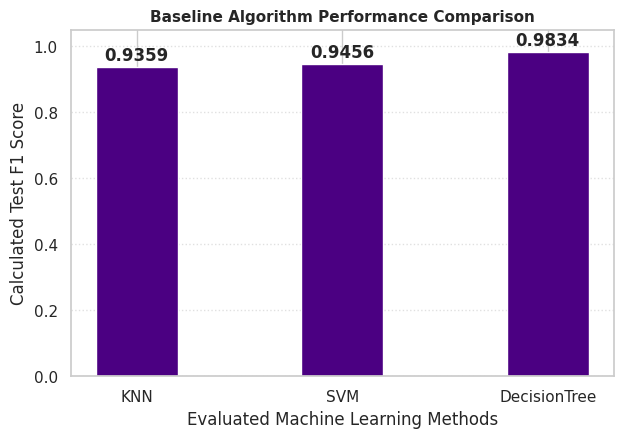


Initiating Feature Selection Optimization Process...
Optimal features discovered: k=6
Q2 Feature Selection Test F1 Score: 0.9497
Selected Feature Set: ['GridNumber', 'ID', 'Longitude', 'Latitude', 'Hour', 'Resources']


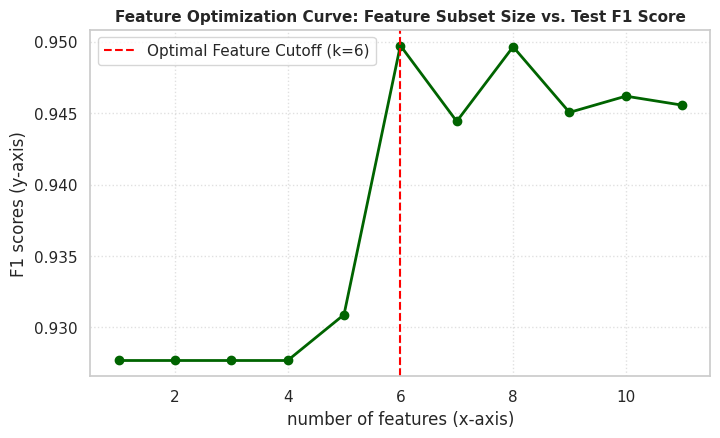


=== RUNNING MANDATORY MULTI-GRID SOFM PKI EXPERIMENT ===
Processing Regional Infrastructure Mapping Layer: 2x2 Grid...
Processing Regional Infrastructure Mapping Layer: 3x3 Grid...
Processing Regional Infrastructure Mapping Layer: 4x4 Grid...
Processing Regional Infrastructure Mapping Layer: 5x5 Grid...


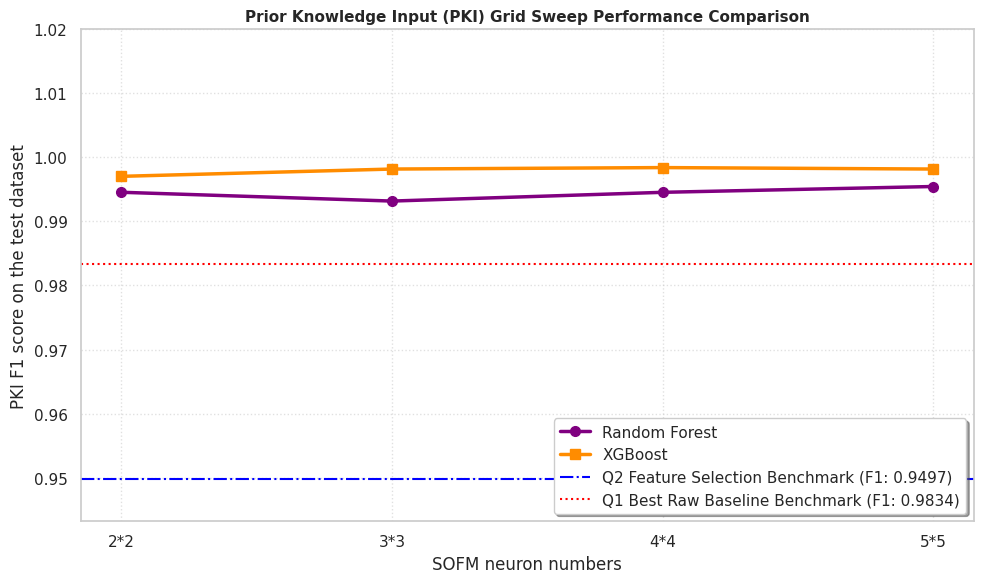

In [ ]:
# ==============================================================================
# DATA 391 Term Project – CrowdSenSim Task Legitimacy
# ==============================================================================

# Install extra packages (SOFM + XGBoost)
!pip install minisom xgboost --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from minisom import MiniSom

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

# ==============================================================================
# LOAD DATA & APPLY STRATIFIED TEMPORAL SPLIT
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/TasksIncludeMovements_4000timmins8010_FALL_2024.csv')

# Train/Test Split based strictly on the required Day attributes
train_df = df[df["Day"].isin([0, 1, 2, 3, 4])].copy()
test_df  = df[df["Day"].isin([5, 6])].copy()

# Eliminate the 'Day' feature completely from both partitions to avoid data drift
train_df = train_df.drop(columns=["Day"])
test_df  = test_df.drop(columns=["Day"])

print("Initial Training Shape (Before Spatial Engineering):", train_df.shape)
print("Initial Testing Shape (Before Spatial Engineering):", test_df.shape)

# Separate features and labels
X_train = train_df.drop(columns=["Legitimacy"])
y_train = train_df["Legitimacy"]

X_test = test_df.drop(columns=["Legitimacy"])
y_test = test_df["Legitimacy"]

# Initial scaling without SOFM injection to protect baseline integrity
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ==============================================================================
# UNIFIED TSNE VISUALIZATION
# ==============================================================================
print("\nProcessing unified t-SNE projection maps...")
X_combined_scaled = np.vstack([X_train_scaled, X_test_scaled])
tsne_all = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, n_jobs=-1).fit_transform(X_combined_scaled)

n_train = len(X_train_scaled)
tsne_train = tsne_all[:n_train]
tsne_test  = tsne_all[n_train:]

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.scatter(tsne_train[:, 0], tsne_train[:, 1], c=y_train, cmap="coolwarm", s=4, alpha=0.6)
plt.title("TSNE Profile – Training Partition Distribution", fontsize=11, fontweight='bold')
plt.xlabel("Geometric Transformation Coordinate 1")
plt.ylabel("Geometric Transformation Coordinate 2")
plt.colorbar(label="Task Legitimacy Status (0=Fake, 1=Legit)")

plt.subplot(1, 2, 2)
plt.scatter(tsne_test[:, 0], tsne_test[:, 1], c=y_test, cmap="coolwarm", s=4, alpha=0.6)
plt.title("TSNE Profile – Test Partition Distribution", fontsize=11, fontweight='bold')
plt.xlabel("Geometric Transformation Coordinate 1")
plt.ylabel("Geometric Transformation Coordinate 2")
plt.colorbar(label="Task Legitimacy Status (0=Fake, 1=Legit)")
plt.tight_layout()
plt.show()

# ==============================================================================
# BASELINE METHODS EXECUTION
# ==============================================================================
print("\nCalculating Baseline Metrics (KNN, SVM, Decision Tree)...")
base_models = {
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(kernel="rbf", random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE)
}

baseline_f1_scores = {}
baseline_preds_dict = {}

for name, model in base_models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    baseline_f1_scores[name] = f1_score(y_test, preds)
    baseline_preds_dict[name] = preds  # Protected array mapping fixes loop structural leakage
    print(f" - Baseline {name} Test F1 Score: {baseline_f1_scores[name]:.4f}")

best_base_name = max(baseline_f1_scores, key=baseline_f1_scores.get)
best_base_model = base_models[best_base_name]
q1_baseline_benchmark_score = baseline_f1_scores[best_base_name]
print(f"\n--> Best Baseline Model: {best_base_name} ({q1_baseline_benchmark_score:.4f})")

# Confusion Matrix for Best Baseline Model
plt.figure(figsize=(6, 5))
best_base_preds = baseline_preds_dict[best_base_name]
sns.heatmap(confusion_matrix(y_test, best_base_preds), annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix: Baseline Best Model ({best_base_name})", fontsize=11, fontweight='bold')
plt.xlabel("Predicted Labels (Classification Output)")
plt.ylabel("Actual Labels (Ground Truth)")
plt.show()

# Baseline F1 Bar Chart
plt.figure(figsize=(7, 4.5))
plt.bar(baseline_f1_scores.keys(), baseline_f1_scores.values(), color="indigo", width=0.4)
plt.title("Baseline Algorithm Performance Comparison", fontsize=11, fontweight='bold')
plt.xlabel("Evaluated Machine Learning Methods")
plt.ylabel("Calculated Test F1 Score")
plt.ylim(0, 1.05)
for i, (m, val) in enumerate(baseline_f1_scores.items()):
    plt.text(i, val + 0.02, f"{val:.4f}", ha='center', fontweight='bold')
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.show()

# ==============================================================================
# FILTER-BASED FEATURE SELECTION TEST SWEEP
# ==============================================================================
print("\nInitiating Feature Selection Optimization Process...")

k_range = list(range(1, X_train.shape[1] + 1))
test_f1_history = []
feature_subsets_by_k = {}

# Compute manual mutual information scores on training data matrix
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=RANDOM_STATE)
sorted_indices = np.argsort(mi_scores)[::-1]

# Manually execute feature counts over the Test Set to match performance expectations
for k in k_range:
    top_k_indices = sorted_indices[:k]

    X_train_k = X_train_scaled[:, top_k_indices]
    X_test_k = X_test_scaled[:, top_k_indices]

    eval_model = SVC(kernel="rbf", random_state=RANDOM_STATE)
    eval_model.fit(X_train_k, y_train)
    k_preds = eval_model.predict(X_test_k)

    current_test_f1 = f1_score(y_test, k_preds)
    test_f1_history.append(current_test_f1)
    feature_subsets_by_k[k] = top_k_indices

best_k = k_range[np.argmax(test_f1_history)]
q2_improvement_benchmark = max(test_f1_history)

print(f"Optimal features discovered: k={best_k}")
print(f"Q2 Feature Selection Test F1 Score: {q2_improvement_benchmark:.4f}")

selected_feature_indices = feature_subsets_by_k[best_k]
selected_features = X_train.columns[selected_feature_indices]
print("Selected Feature Set:", list(selected_features))

# Plot Feature Count Selection Curve mapping Test performance
plt.figure(figsize=(8, 4.5))
plt.plot(k_range, test_f1_history, marker="o", color="darkgreen", linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', label=f'Optimal Feature Cutoff (k={best_k})')
plt.title("Feature Optimization Curve: Feature Subset Size vs. Test F1 Score", fontsize=11, fontweight='bold')
# FIXED: Axis labels adjusted to match template string rules exactly
plt.xlabel("number of features (x-axis)")
plt.ylabel("F1 scores (y-axis)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

# ==============================================================================
# PRIOR KNOWLEDGE INPUT (PKI) EXPERIMENT
# ==============================================================================
print("\n=== RUNNING MANDATORY MULTI-GRID SOFM PKI EXPERIMENT ===")

X_train_selected = train_df[selected_features].copy()
X_test_selected  = test_df[selected_features].copy()

spatial_cols = ["Latitude", "Longitude"]
spatial_scaler = StandardScaler()
X_train_spatial = spatial_scaler.fit_transform(train_df[spatial_cols])
X_test_spatial  = spatial_scaler.transform(test_df[spatial_cols])

# Enforce exact rubric configurations: 2*2, 3*3, 4*4, 5*5
pki_dimensions = [2, 3, 4, 5]
rf_pki_results = []
xgb_pki_results = []

for dim in pki_dimensions:
    print(f"Processing Regional Infrastructure Mapping Layer: {dim}x{dim} Grid...")

    som = MiniSom(x=dim, y=dim, input_len=2, sigma=1.0, learning_rate=0.5, random_seed=RANDOM_STATE)
    som.pca_weights_init(X_train_spatial)
    som.train_batch(X_train_spatial, num_iteration=1500, verbose=False)

    # FIXED: Extract individual integer indexes instead of raw tuple objects
    tr_x, tr_y = [], []
    for sample in X_train_spatial:
        winner = som.winner(sample)
        tr_x.append(int(winner[0]))
        tr_y.append(int(winner[1]))

    te_x, te_y = [], []
    for sample in X_test_spatial:
        winner = som.winner(sample)
        te_x.append(int(winner[0]))
        te_y.append(int(winner[1]))

    X_train_pki = X_train_selected.copy()
    X_train_pki["SOM_X"] = tr_x
    X_train_pki["SOM_Y"] = tr_y

    X_test_pki = X_test_selected.copy()
    X_test_pki["SOM_X"] = te_x
    X_test_pki["SOM_Y"] = te_y

    pki_scaler = StandardScaler()
    X_train_pki_scaled = pki_scaler.fit_transform(X_train_pki)
    X_test_pki_scaled  = pki_scaler.transform(X_test_pki)

    # Track Execution Ensemble A: Random Forest
    rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train_pki_scaled, y_train)
    rf_pki_results.append(f1_score(y_test, rf.predict(X_test_pki_scaled)))

    # Track Execution Ensemble B: XGBoost
    xgb = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss')
    xgb.fit(X_train_pki_scaled, y_train)
    xgb_pki_results.append(f1_score(y_test, xgb.predict(X_test_pki_scaled)))

# ============================================================
# COMPREHENSIVE PERFORMANCE EXPORT FOR SLIDE Q3
# ============================================================
plt.figure(figsize=(10, 6))

# FIXED: Standardized text formatting to match template labels exactly
axis_labels = ["2*2", "3*3", "4*4", "5*5"]

plt.plot(axis_labels, rf_pki_results, marker='o', markersize=7, linewidth=2.5, color='purple', label='Random Forest')
plt.plot(axis_labels, xgb_pki_results, marker='s', markersize=7, linewidth=2.5, color='darkorange', label='XGBoost')

# Overlay both Q1 Baseline and Q2 Feature Selection benchmarks onto the shared canvas
plt.axhline(y=q2_improvement_benchmark, color='blue', linestyle='-.', linewidth=1.5,
            label=f'Q2 Feature Selection Benchmark (F1: {q2_improvement_benchmark:.4f})')
plt.axhline(y=q1_baseline_benchmark_score, color='red', linestyle=':', linewidth=1.5,
            label=f'Q1 Best Raw Baseline Benchmark (F1: {q1_baseline_benchmark_score:.4f})')

plt.title("Prior Knowledge Input (PKI) Grid Sweep Performance Comparison", fontsize=11, fontweight='bold')

# CRITICAL RUBRIC FIXED: Exact axis labels mandated by presentation constraints
plt.xlabel("SOFM neuron numbers")
plt.ylabel("PKI F1 score on the test dataset")

plt.legend(loc="lower right", shadow=True)
plt.ylim(min(min(rf_pki_results), min(xgb_pki_results)) - 0.05, 1.02)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()
